# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan (Jaya Jaya Institut)

- Nama: [Nama Lengkap]
- Email: [Email]
- Id Dicoding: [ID Dicoding]

## Business Understanding

### Latar Belakang
Jaya Jaya Institut adalah institusi pendidikan tinggi yang berdiri sejak tahun 2000 dan telah mencetak banyak lulusan dengan reputasi baik. Namun, jumlah mahasiswa yang tidak menyelesaikan pendidikannya (**dropout**) masih tinggi. Hal ini merugikan institusi, baik dari sisi reputasi, akreditasi, maupun pendapatan, dan tentu merugikan mahasiswa itu sendiri.

Jaya Jaya Institut ingin **mendeteksi sedini mungkin mahasiswa yang berpotensi dropout** agar dapat diberikan bimbingan khusus.

### Permasalahan Bisnis
1. Seberapa besar tingkat dropout di Jaya Jaya Institut?
2. Faktor apa saja (akademik, finansial, demografis, jalur masuk) yang paling berkaitan dengan dropout?
3. Bagaimana cara mendeteksi mahasiswa berisiko dropout sejak dini secara otomatis?
4. Bagaimana institusi dapat memonitor performa mahasiswa secara berkelanjutan?

### Tujuan Proyek
1. Melakukan analisis data untuk mengidentifikasi faktor-faktor utama penyebab dropout.
2. Membangun model machine learning klasifikasi untuk memprediksi apakah seorang mahasiswa berisiko dropout.
3. Menyediakan prototype aplikasi (Streamlit) agar staf akademik dapat menggunakan model tersebut.
4. Menyediakan dashboard (Metabase) untuk memonitor performa mahasiswa.

## Persiapan

### Menyiapkan library yang dibutuhkan
Library yang digunakan:
- `pandas` & `numpy` untuk manipulasi data,
- `matplotlib` & `seaborn` untuk visualisasi,
- `scikit-learn` untuk preprocessing, modeling, dan evaluasi,
- `joblib` untuk menyimpan model,
- `sqlite3` untuk menyimpan data bersih ke database yang dibaca Metabase,
- `utils.py` (modul lokal) berisi mapping label dan fungsi *feature engineering* yang juga dipakai oleh aplikasi Streamlit, sehingga transformasi data di notebook dan aplikasi selalu identik.

In [1]:
import json
import sqlite3
import warnings

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report, f1_score,
                             precision_recall_curve, precision_score, recall_score,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_predict,
                                     cross_validate, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

from utils import (CATEGORICAL_FEATURES, ENGINEERED_FEATURES, MODEL_FEATURES,
                   NUMERIC_FEATURES, add_engineered_features, add_labels)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
RANDOM_STATE = 42
print("scikit-learn", sklearn.__version__, "| pandas", pd.__version__)

scikit-learn 1.9.1 | pandas 3.0.6


Gaya visualisasi dibuat konsisten di seluruh notebook:
- **Warna status tetap**: Dropout = oranye, Enrolled = hijau aqua, Graduate = biru (palet ini sudah divalidasi aman untuk pembaca buta warna).
- Pada grafik *dropout rate*, batang **oranye** menandai kategori dengan dropout rate **di atas rata-rata** institusi, sedangkan batang abu-abu berada di bawah rata-rata. Garis putus-putus menunjukkan rata-rata keseluruhan.
- Sumbu persentase selalu dimulai dari 0 dan setiap batang diberi label nilai beserta jumlah mahasiswa (n) agar perbandingan jujur dan tidak menyesatkan.

In [2]:
STATUS_ORDER = ["Dropout", "Enrolled", "Graduate"]
STATUS_COLORS = {"Dropout": "#eb6834", "Enrolled": "#1baf7a", "Graduate": "#2a78d6"}
HIGHLIGHT, NEUTRAL = "#eb6834", "#c3c2b7"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e1e0d9"

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": MUTED,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.size": 10,
    "legend.frameon": False,
})

### Menyiapkan data yang akan digunakan
Dataset *Students' Performance* berisi 4.424 data mahasiswa dari berbagai program studi. Berkas CSV menggunakan pemisah titik koma (`;`).

In [3]:
df = pd.read_csv("data/data.csv", sep=";")
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

### Struktur dan kualitas data

In [4]:
print(f"Jumlah baris: {df.shape[0]:,} | Jumlah kolom: {df.shape[1]}")
df.info()

Jumlah baris: 4,424 | Jumlah kolom: 37


<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   int64  
 10 

In [5]:
print("Total missing value :", df.isna().sum().sum())
print("Total baris duplikat:", df.duplicated().sum())

Total missing value : 0
Total baris duplikat: 0


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application_mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application_order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime_evening_attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous_qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous_qualification_grade,4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mothers_qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Fathers_qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


**Insight:**
- Dataset terdiri dari **4.424 baris dan 37 kolom** (36 fitur + 1 target `Status`).
- **Tidak ada missing value maupun data duplikat**, sehingga tidak diperlukan imputasi atau penghapusan baris.
- Seluruh fitur bertipe numerik, tetapi banyak di antaranya sebenarnya **kategorikal yang dikodekan dengan angka** (misalnya `Course`, `Application_mode`, `Marital_status`). Agar mudah dianalisis, kode-kode tersebut akan dipetakan ke label menggunakan fungsi `add_labels()` dari `utils.py`.
- Nilai-nilai berada dalam rentang yang wajar sesuai dokumentasi (nilai masuk 95–190 dari skala 0–200, nilai semester 0–20, usia 17–70 tahun). Nilai ekstrem seperti usia 70 tahun adalah kasus nyata (mahasiswa dewasa), bukan kesalahan input, sehingga tetap dipertahankan.

Kelompok fitur pada dataset:

| Kelompok | Contoh fitur |
|---|---|
| Demografi | `Marital_status`, `Gender`, `Age_at_enrollment`, `Nacionality`, `International`, `Displaced` |
| Jalur masuk & latar belakang akademik | `Application_mode`, `Application_order`, `Course`, `Previous_qualification(_grade)`, `Admission_grade` |
| Sosial-ekonomi keluarga | `Mothers/Fathers_qualification`, `Mothers/Fathers_occupation` |
| Finansial | `Debtor`, `Tuition_fees_up_to_date`, `Scholarship_holder` |
| Performa akademik semester 1 & 2 | `Curricular_units_*_sem_(credited/enrolled/evaluations/approved/grade/without_evaluations)` |
| Makroekonomi | `Unemployment_rate`, `Inflation_rate`, `GDP` |

In [7]:
df_eda = add_engineered_features(add_labels(df))
df_eda["Status"] = pd.Categorical(df_eda["Status"], categories=STATUS_ORDER, ordered=True)
df_eda["Is_dropout"] = (df_eda["Status"] == "Dropout").astype(int)
df_eda["Age_group"] = pd.cut(df_eda["Age_at_enrollment"], bins=[0, 20, 24, 29, 39, 100],
                             labels=["<=20", "21-24", "25-29", "30-39", "40+"])
OVERALL_DROPOUT = df_eda["Is_dropout"].mean()
df_eda[["Course", "Course_label", "Application_mode_label", "Gender_label", "Status"]].head()

,Course,Course_label,Application_mode_label,Gender_label,Status
0,171,Animation and Multimedia Design,2nd phase - general contingent,Male,Dropout
1,9254,Tourism,International student (bachelor),Male,Graduate
2,9070,Communication Design,1st phase - general contingent,Male,Dropout
3,9773,Journalism and Communication,2nd phase - general contingent,Female,Graduate
4,8014,Social Service (evening attendance),Over 23 years old,Female,Graduate


### Exploratory Data Analysis (EDA)

#### 1. Distribusi status mahasiswa

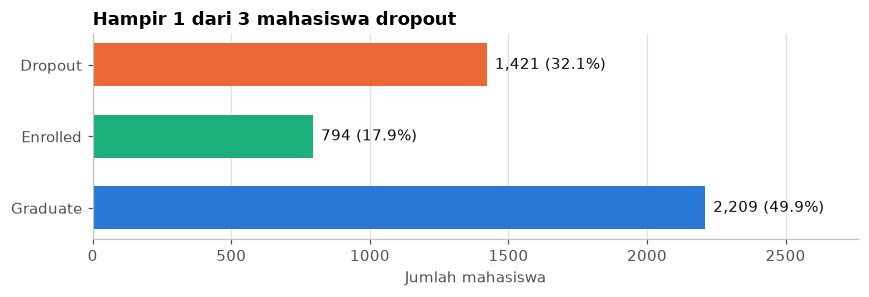

In [8]:
status = df_eda["Status"].value_counts().reindex(STATUS_ORDER)
fig, ax = plt.subplots(figsize=(8, 2.8))
bars = ax.barh(status.index[::-1], status.values[::-1],
               color=[STATUS_COLORS[s] for s in status.index[::-1]], height=0.6)
for b, v in zip(bars, status.values[::-1]):
    ax.text(b.get_width() + 30, b.get_y() + b.get_height() / 2,
            f"{v:,} ({v / len(df_eda):.1%})", va="center", color=INK)
ax.set_xlim(0, status.max() * 1.25)
ax.set_xlabel("Jumlah mahasiswa")
ax.grid(axis="y", visible=False)
ax.set_title("Hampir 1 dari 3 mahasiswa dropout")
plt.tight_layout()
plt.show()

**Insight:**
- **32,1% mahasiswa (1.421 orang) dropout**, angka yang sangat tinggi dan menjadi inti masalah Jaya Jaya Institut.
- 49,9% lulus (*Graduate*) dan 17,9% masih terdaftar (*Enrolled*) setelah masa studi normal, artinya terlambat lulus.
- Untuk pemodelan, kelas *Dropout* (32%) vs *Non-Dropout* (68%) cukup tidak seimbang, sehingga evaluasi model akan menggunakan **F1-score, recall, dan ROC-AUC**, bukan sekadar akurasi.

#### Fungsi bantu visualisasi dropout rate

In [9]:
def dropout_rate_table(col, min_n=0, sort=True):
    t = df_eda.groupby(col, observed=True)["Is_dropout"].agg(rate="mean", n="size")
    t = t[t["n"] >= min_n]
    return t.sort_values("rate") if sort else t


def plot_dropout_rate(ax, col, title, min_n=0, sort=True):
    """Bar chart horizontal dropout rate per kategori.

    sort=True  -> kategori nominal diurutkan dari dropout rate terendah ke tertinggi.
    sort=False -> kategori ordinal (usia, jumlah MK) ditampilkan sesuai urutan aslinya dari atas ke bawah.
    """
    t = dropout_rate_table(col, min_n, sort)
    colors = [HIGHLIGHT if r > OVERALL_DROPOUT else NEUTRAL for r in t["rate"]]
    bars = ax.barh(t.index.astype(str), t["rate"] * 100, color=colors, height=0.6)
    for b, (r, n) in zip(bars, t[["rate", "n"]].values):
        ax.text(b.get_width() + 1.5, b.get_y() + b.get_height() / 2,
                f"{r:.0%}  (n={int(n):,})", va="center", fontsize=9, color=MUTED,
                bbox={"facecolor": "white", "edgecolor": "none", "pad": 1})
    ax.axvline(OVERALL_DROPOUT * 100, color=INK, ls="--", lw=1, zorder=1)
    ax.set_xlim(0, 105)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlabel(f"Dropout rate  (garis putus-putus = rata-rata {OVERALL_DROPOUT:.0%})")
    ax.grid(axis="y", visible=False)
    ax.set_title(title)
    if not sort:
        ax.invert_yaxis()
    return t

#### 2. Performa akademik semester 1 & 2

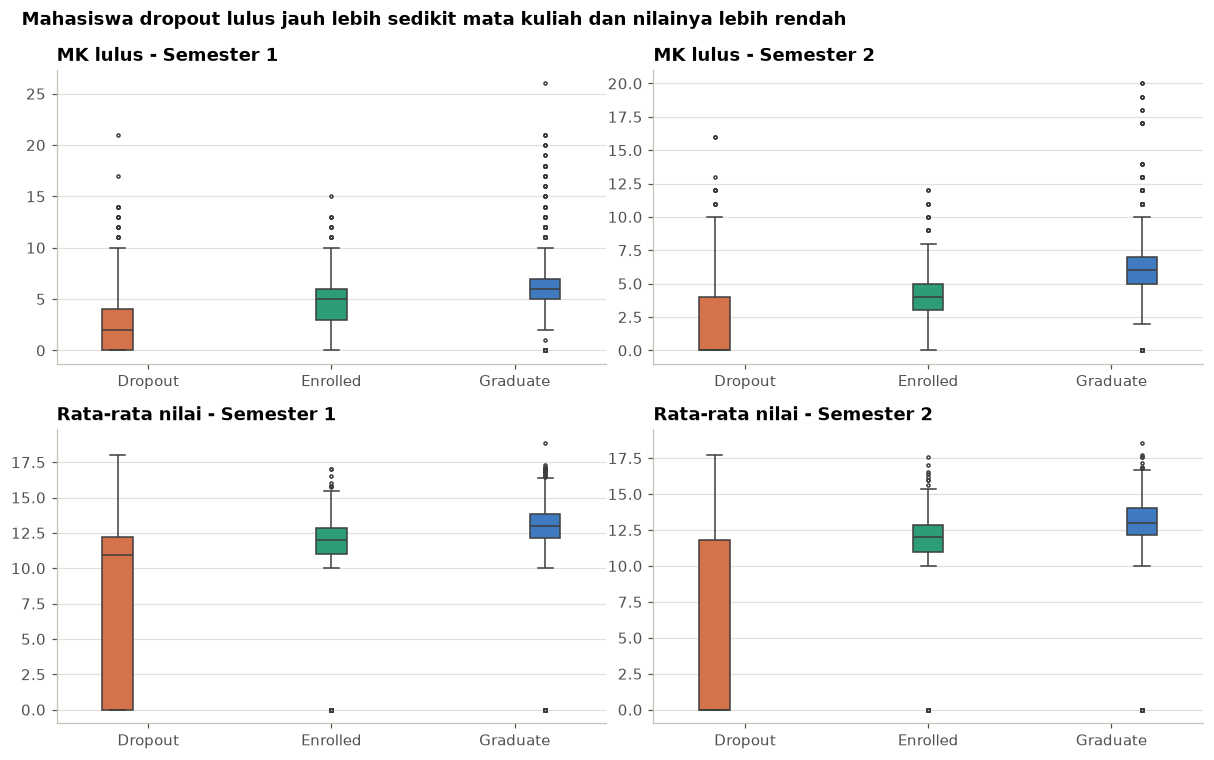

Status,Dropout,Enrolled,Graduate
Curricular_units_1st_sem_approved,2.00,5.00,6.0
Curricular_units_2nd_sem_approved,0.00,4.00,6.0
Curricular_units_1st_sem_grade,10.93,12.00,13.0
Curricular_units_2nd_sem_grade,0.00,12.00,13.0
Approval_rate_1st_sem,0.33,0.80,1.0
Approval_rate_2nd_sem,0.00,0.69,1.0


In [10]:
academic_cols = {
    "Curricular_units_1st_sem_approved": "MK lulus - Semester 1",
    "Curricular_units_2nd_sem_approved": "MK lulus - Semester 2",
    "Curricular_units_1st_sem_grade": "Rata-rata nilai - Semester 1",
    "Curricular_units_2nd_sem_grade": "Rata-rata nilai - Semester 2",
}
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, (col, label) in zip(axes.ravel(), academic_cols.items()):
    sns.boxplot(data=df_eda, x="Status", y=col, hue="Status", order=STATUS_ORDER,
                palette=STATUS_COLORS, width=0.5, fliersize=2, linewidth=1, legend=False, ax=ax)
    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.suptitle("Mahasiswa dropout lulus jauh lebih sedikit mata kuliah dan nilainya lebih rendah",
             x=0.01, ha="left", fontweight="bold")
plt.tight_layout()
plt.show()

df_eda.groupby("Status", observed=True)[list(academic_cols) + ENGINEERED_FEATURES].median().round(2).T

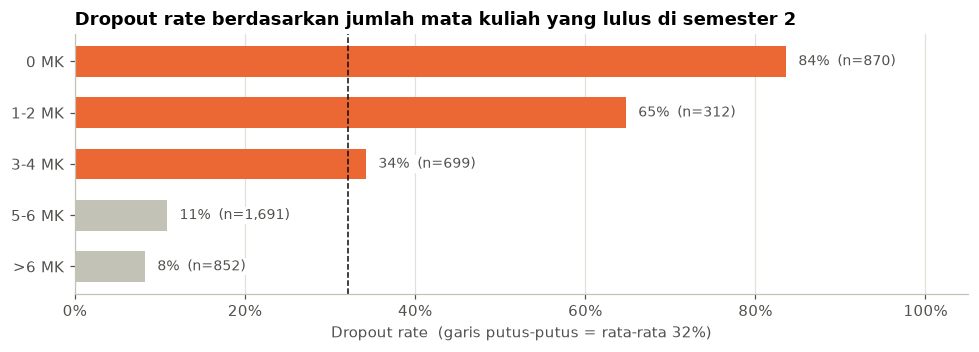

In [11]:
df_eda["Approved_2nd_group"] = pd.cut(df_eda["Curricular_units_2nd_sem_approved"],
                                      bins=[-1, 0, 2, 4, 6, 100],
                                      labels=["0 MK", "1-2 MK", "3-4 MK", "5-6 MK", ">6 MK"])
fig, ax = plt.subplots(figsize=(9, 3.3))
t = plot_dropout_rate(ax, "Approved_2nd_group",
                      "Dropout rate berdasarkan jumlah mata kuliah yang lulus di semester 2", sort=False)
plt.tight_layout()
plt.show()

**Insight:**
- Performa akademik adalah **pembeda paling kuat**. Median jumlah mata kuliah (MK) yang lulus pada mahasiswa dropout hanya **2 MK di semester 1 dan 0 MK di semester 2**, dibanding 6 MK pada mahasiswa yang lulus.
- Median rasio kelulusan MK (*approval rate*) mahasiswa dropout hanya 33% di semester 1 dan 0% di semester 2, sementara mahasiswa Graduate 100%.
- Terdapat **870 mahasiswa yang tidak lulus satu pun MK di semester 2**, dan **84%** di antaranya dropout. Semakin banyak MK yang lulus, dropout rate turun drastis.
- Artinya, **nilai dan kelulusan MK di semester 1–2 adalah sinyal peringatan dini terbaik**. Mahasiswa dengan approval rate rendah sejak semester 1 perlu segera mendapat intervensi akademik.
- Mahasiswa *Enrolled* berada di tengah: performanya lebih rendah dari Graduate, tetapi jauh di atas Dropout.

#### 3. Faktor finansial

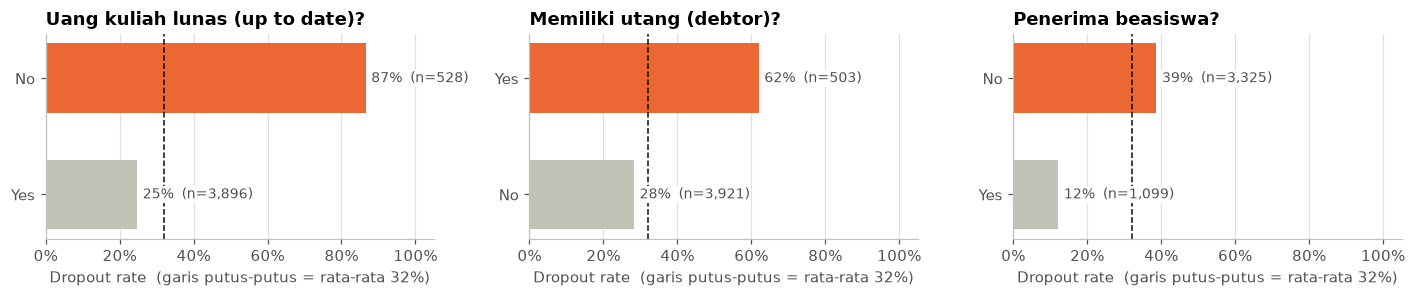

Mahasiswa yang menunggak uang kuliah DAN memiliki utang: 246 orang, dropout rate 87.4%


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 2.8), sharex=True)
plot_dropout_rate(axes[0], "Tuition_fees_up_to_date_label", "Uang kuliah lunas (up to date)?")
plot_dropout_rate(axes[1], "Debtor_label", "Memiliki utang (debtor)?")
plot_dropout_rate(axes[2], "Scholarship_holder_label", "Penerima beasiswa?")
plt.tight_layout()
plt.show()

both = df_eda[(df_eda["Tuition_fees_up_to_date"] == 0) & (df_eda["Debtor"] == 1)]
print(f"Mahasiswa yang menunggak uang kuliah DAN memiliki utang: {len(both)} orang, "
      f"dropout rate {both['Is_dropout'].mean():.1%}")

**Insight:**
- **Tunggakan uang kuliah adalah faktor non-akademik terkuat.** Dropout rate mahasiswa yang uang kuliahnya tidak lunas mencapai **87%**, jauh di atas yang lunas (25%).
- Mahasiswa yang memiliki utang (*debtor*) memiliki dropout rate **62%**, lebih dari dua kali lipat mahasiswa tanpa utang (28%).
- Jika kedua kondisi terjadi bersamaan (menunggak dan berutang), dropout rate mencapai sekitar **87%**.
- Sebaliknya, **penerima beasiswa jauh lebih jarang dropout (12%)** dibanding non-penerima (39%). Dukungan finansial terbukti berkaitan dengan keberlanjutan studi.

#### 4. Faktor demografis

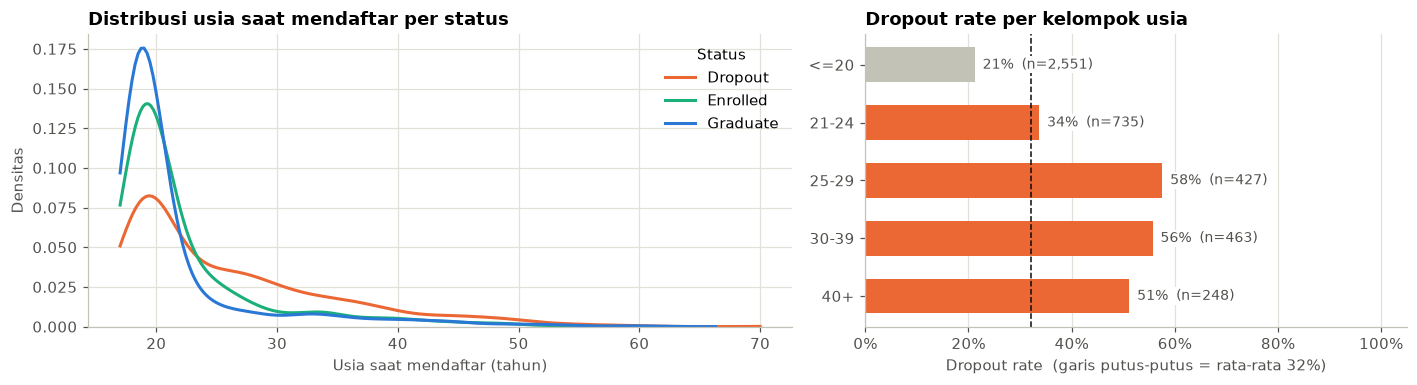

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), gridspec_kw={"width_ratios": [1.3, 1]})
for s in STATUS_ORDER:
    sns.kdeplot(data=df_eda[df_eda["Status"] == s], x="Age_at_enrollment", ax=axes[0],
                color=STATUS_COLORS[s], lw=2, label=s, common_norm=False, clip=(17, 70))
axes[0].set_title("Distribusi usia saat mendaftar per status")
axes[0].set_xlabel("Usia saat mendaftar (tahun)")
axes[0].set_ylabel("Densitas")
axes[0].legend(title="Status")
plot_dropout_rate(axes[1], "Age_group", "Dropout rate per kelompok usia", sort=False)
plt.tight_layout()
plt.show()

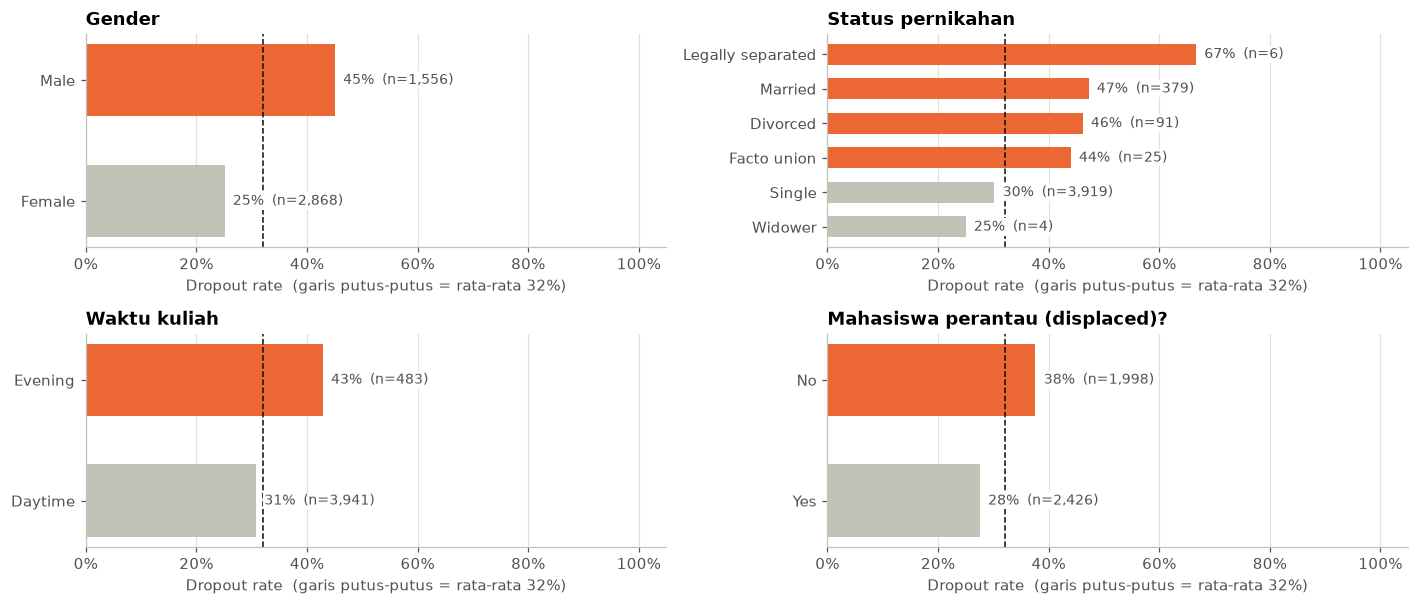

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 5.6))
plot_dropout_rate(axes[0, 0], "Gender_label", "Gender")
plot_dropout_rate(axes[0, 1], "Marital_status_label", "Status pernikahan")
plot_dropout_rate(axes[1, 0], "Attendance_label", "Waktu kuliah")
plot_dropout_rate(axes[1, 1], "Displaced_label", "Mahasiswa perantau (displaced)?")
plt.tight_layout()
plt.show()

**Insight:**
- **Usia saat mendaftar** berpengaruh besar. Mahasiswa berusia ≤20 tahun memiliki dropout rate 21%, sedangkan mahasiswa berusia **25 tahun ke atas lebih dari 50%**. Mahasiswa dewasa cenderung memiliki tanggungan lain (pekerjaan, keluarga) yang bersaing dengan studi.
- Mahasiswa **laki-laki** memiliki dropout rate **45%**, jauh di atas perempuan (25%).
- Mahasiswa yang **menikah/bercerai** dan yang mengikuti **kelas malam** juga lebih berisiko. Ini konsisten dengan profil mahasiswa dewasa yang bekerja.
- Menariknya, mahasiswa perantau (*displaced*) justru sedikit lebih jarang dropout (28% vs 38%). Kemungkinan besar karena mereka umumnya lebih muda (baru lulus SMA).
- Kategori dengan n sangat kecil (misalnya *Legally separated*, n=6) perlu dibaca dengan hati-hati.

#### 5. Program studi dan jalur masuk

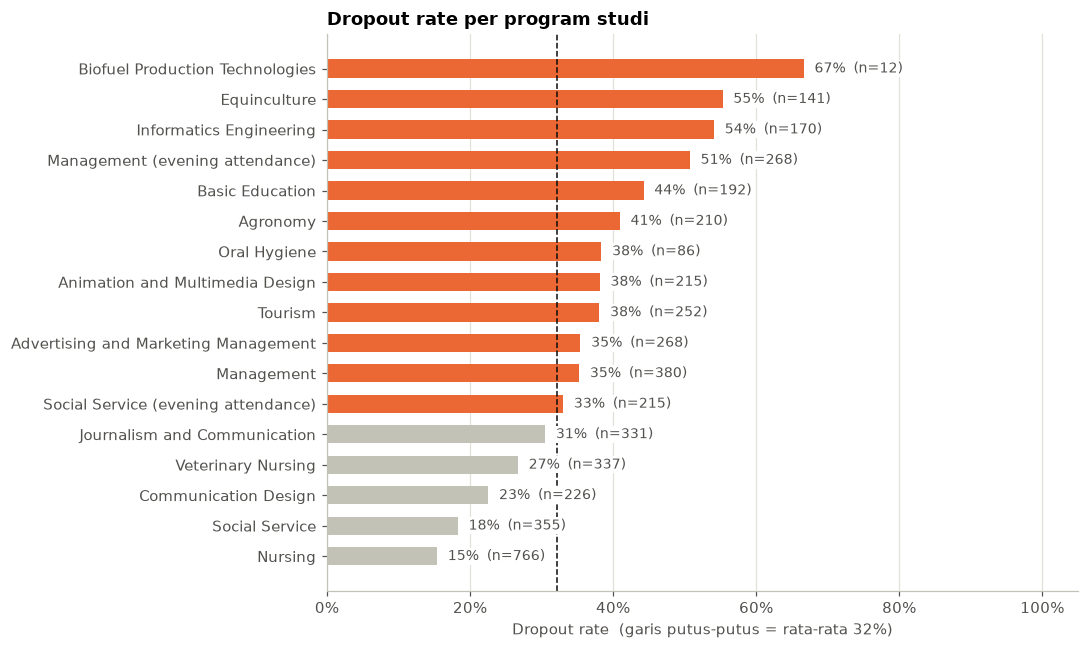

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_dropout_rate(ax, "Course_label", "Dropout rate per program studi")
plt.tight_layout()
plt.show()

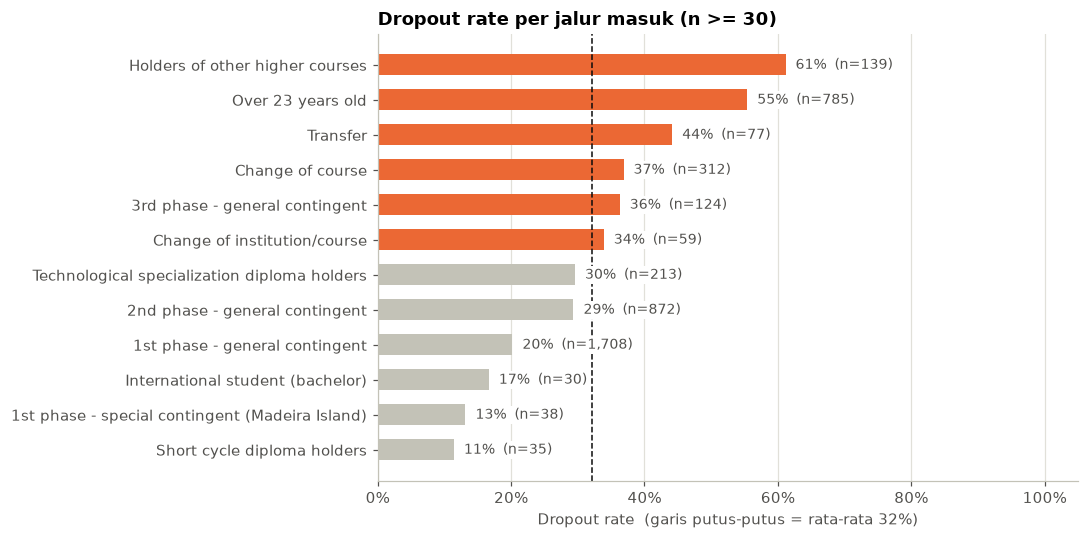

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_dropout_rate(ax, "Application_mode_label", "Dropout rate per jalur masuk (n >= 30)", min_n=30)
plt.tight_layout()
plt.show()

**Insight:**
- Dropout rate sangat bervariasi antar program studi. **Nursing (15%) dan Social Service (18%)** paling rendah, sedangkan **Equinculture (55%), Informatics Engineering (54%), dan Management kelas malam (51%)** paling tinggi. *Biofuel Production Technologies* (67%) hanya memiliki 12 mahasiswa, sehingga kurang representatif.
- Dari sisi jalur masuk, mahasiswa jalur **"Over 23 years old" (55%, n=785)** dan **"Holders of other higher courses" (61%)** paling berisiko. Temuan ini menguatkan insight usia: jalur untuk mahasiswa dewasa adalah kelompok rentan.
- Jalur reguler **"1st phase - general contingent"** (jalur terbanyak, n=1.708) memiliki dropout rate terendah di antara jalur besar (20%).

#### 6. Latar belakang orang tua dan kondisi makroekonomi

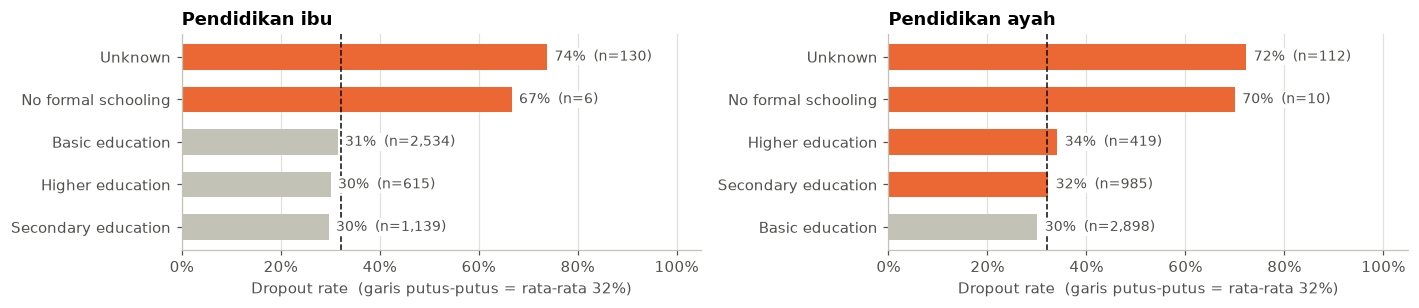

Rentang dropout rate antar nilai unemployment rate: 24% - 38% | korelasi dengan dropout: 0.013


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 2.9))
plot_dropout_rate(axes[0], "Mothers_education_label", "Pendidikan ibu")
plot_dropout_rate(axes[1], "Fathers_education_label", "Pendidikan ayah")
plt.tight_layout()
plt.show()

macro = df_eda.groupby("Unemployment_rate")["Is_dropout"].mean()
print("Rentang dropout rate antar nilai unemployment rate:",
      f"{macro.min():.0%} - {macro.max():.0%}",
      f"| korelasi dengan dropout: {df_eda['Unemployment_rate'].corr(df_eda['Is_dropout']):.3f}")

**Insight:**
- Selain kategori *Unknown* (data pendidikan orang tua tidak diketahui, 74% dropout), **tingkat pendidikan orang tua hampir tidak membedakan dropout rate** (±30% di semua jenjang). Tingginya dropout pada kategori *Unknown* kemungkinan mencerminkan data pendaftaran yang tidak lengkap, bukan faktor pendidikan itu sendiri.
- Indikator makroekonomi (*unemployment rate*, inflasi, GDP) hanya memiliki 10 nilai unik (mengikuti tahun masuk) dan korelasinya dengan dropout sangat lemah. Selain itu, faktor ini **tidak dapat diintervensi** oleh institusi.

#### 7. Korelasi fitur numerik dengan dropout
Korelasi dihitung antara setiap fitur numerik/biner dan indikator dropout (1 = Dropout, 0 = lainnya). Fitur kategorikal nominal yang dikodekan angka (misalnya `Course`) tidak diikutkan karena korelasi pada kode nominal tidak bermakna.

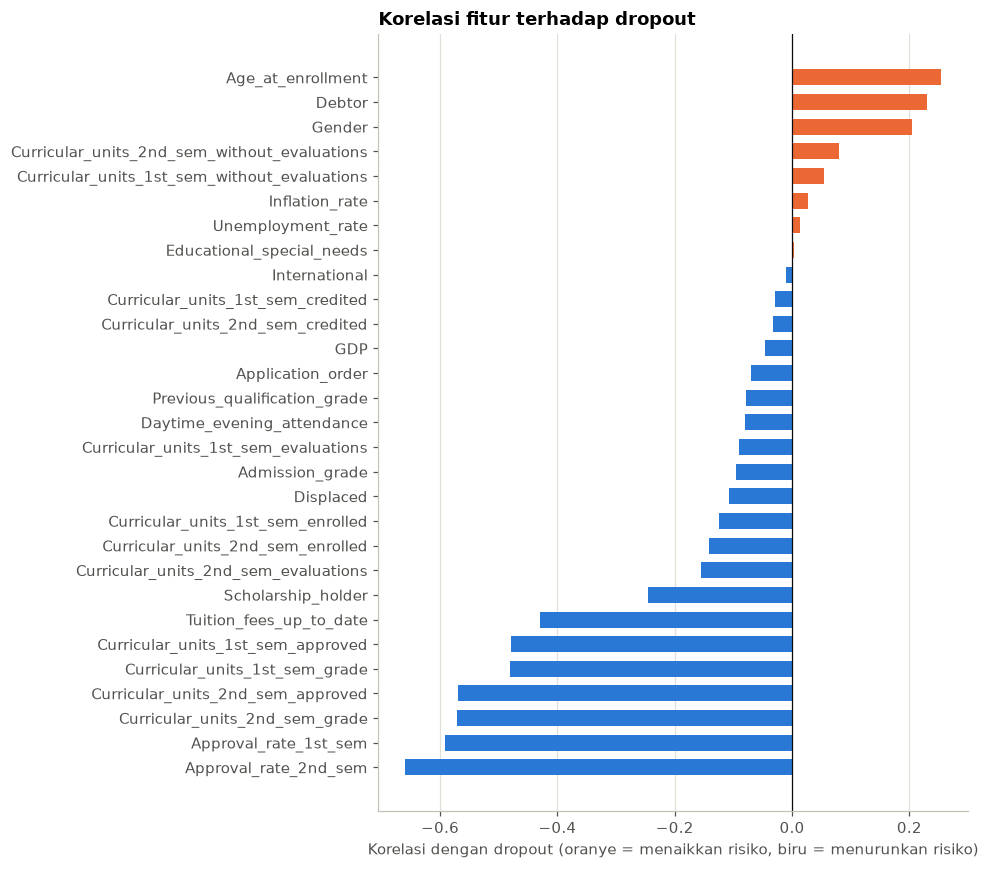

In [18]:
nominal_codes = ["Marital_status", "Application_mode", "Course", "Previous_qualification", "Nacionality",
                 "Mothers_qualification", "Fathers_qualification", "Mothers_occupation", "Fathers_occupation"]
num_cols = [c for c in df.columns if c not in nominal_codes + ["Status"]] + ENGINEERED_FEATURES
corr = df_eda[num_cols].corrwith(df_eda["Is_dropout"]).sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(corr.index, corr.values, color=[HIGHLIGHT if v > 0 else "#2a78d6" for v in corr.values], height=0.65)
ax.axvline(0, color=INK, lw=0.8)
ax.set_xlabel("Korelasi dengan dropout (oranye = menaikkan risiko, biru = menurunkan risiko)")
ax.grid(axis="y", visible=False)
ax.set_title("Korelasi fitur terhadap dropout")
plt.tight_layout()
plt.show()

**Insight:**
- Korelasi negatif terkuat (faktor pelindung): **approval rate dan jumlah MK lulus di semester 2 & 1, nilai rata-rata semester, uang kuliah lunas, dan status penerima beasiswa**.
- Korelasi positif terkuat (faktor risiko): **usia saat mendaftar, status debtor, dan gender laki-laki**.
- Fitur makroekonomi, kebutuhan khusus, dan status internasional memiliki korelasi mendekati nol.

**Ringkasan EDA - faktor utama dropout:**
1. **Akademik**: jumlah MK lulus dan nilai rendah di semester 1–2 (faktor terkuat).
2. **Finansial**: tunggakan uang kuliah, memiliki utang, tidak menerima beasiswa.
3. **Demografis**: usia masuk ≥25 tahun, laki-laki, sudah menikah, kuliah malam.
4. **Jalur masuk & program studi**: jalur *Over 23 years old*, serta prodi seperti Equinculture, Informatics Engineering, dan Management (malam).

## Data Preparation / Preprocessing

### 1. Menentukan target
Sesuai kebutuhan bisnis (mendeteksi mahasiswa yang berisiko **dropout**), target dibuat menjadi **biner**:
- `1` = **Dropout**
- `0` = **Non-Dropout** (*Graduate* dan *Enrolled*)

Status *Enrolled* berarti mahasiswa masih terdaftar setelah masa studi normal berakhir (terlambat lulus), tetapi **belum/tidak dropout**. Karena itu, mereka digabung ke kelas Non-Dropout. Seluruh 4.424 data tetap digunakan.

In [19]:
y = (df["Status"] == "Dropout").astype(int)
y.value_counts().rename(index={1: "Dropout", 0: "Non-Dropout"}).to_frame("jumlah").assign(
    proporsi=lambda t: (t["jumlah"] / t["jumlah"].sum()).round(3))

,jumlah,proporsi
Status,,
Non-Dropout,3003,0.679
Dropout,1421,0.321


### 2. Seleksi fitur
Berdasarkan EDA, dipilih **20 fitur** yang relevan dan dapat diketahui institusi, dengan pertimbangan:

| Dipertahankan | Alasan |
|---|---|
| Performa akademik semester 1 & 2 (MK diambil, dievaluasi, lulus, nilai) | Faktor terkuat |
| `Tuition_fees_up_to_date`, `Debtor`, `Scholarship_holder` | Faktor finansial yang kuat |
| `Age_at_enrollment`, `Gender`, `Marital_status`, `Displaced`, `Daytime_evening_attendance` | Faktor demografis yang berpengaruh |
| `Application_mode`, `Course`, `Admission_grade`, `Previous_qualification_grade` | Jalur masuk, prodi, dan kemampuan awal |

| Dibuang | Alasan |
|---|---|
| `Unemployment_rate`, `Inflation_rate`, `GDP` | Korelasi sangat lemah, tidak spesifik per mahasiswa, dan tidak dapat diintervensi |
| Pendidikan & pekerjaan orang tua | Hampir tidak membedakan dropout; kardinalitas sangat tinggi (>30 kode) |
| `Nacionality`, `International`, `Educational_special_needs` | Korelasi mendekati nol dan kategorinya sangat jarang |
| `Previous_qualification`, `Application_order` | Informasi sudah terwakili oleh fitur lain, kontribusi kecil |
| `*_credited`, `*_without_evaluations` | Kontribusi kecil, didominasi nilai 0 |

Fitur yang lebih sedikit juga membuat **prototype aplikasi lebih mudah digunakan** karena form input tidak terlalu panjang. Pada tahap modeling akan dibuktikan bahwa seleksi fitur ini tidak menurunkan performa secara berarti.

In [20]:
X = df[MODEL_FEATURES].copy()
print(f"Jumlah fitur terpilih: {len(MODEL_FEATURES)}")
print("Kategorikal:", CATEGORICAL_FEATURES)
print("Numerik    :", NUMERIC_FEATURES)

Jumlah fitur terpilih: 20
Kategorikal: ['Marital_status', 'Application_mode', 'Course']
Numerik    : ['Daytime_evening_attendance', 'Admission_grade', 'Previous_qualification_grade', 'Displaced', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade']


### 3. Feature engineering
Ditambahkan 2 fitur turunan, yaitu **approval rate** per semester = MK lulus / MK diambil (0 jika tidak mengambil MK). Rasio ini lebih adil dibanding jumlah absolut karena beban MK tiap prodi berbeda. Fungsi `add_engineered_features()` diletakkan di `utils.py` dan dijalankan **di dalam pipeline**, sehingga aplikasi cukup mengirim 20 fitur mentah.

In [21]:
add_engineered_features(X.head())[["Curricular_units_1st_sem_enrolled", "Curricular_units_1st_sem_approved",
                                   "Approval_rate_1st_sem", "Curricular_units_2nd_sem_enrolled",
                                   "Curricular_units_2nd_sem_approved", "Approval_rate_2nd_sem"]]

,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_approved,Approval_rate_1st_sem,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_approved,Approval_rate_2nd_sem
0,0,0,0.000000,0,0,0.000000
1,6,6,1.000000,6,6,1.000000
2,6,0,0.000000,6,0,0.000000
3,6,6,1.000000,6,5,0.833333
4,6,5,0.833333,6,6,1.000000


### 4. Pembagian data latih dan uji
Data dibagi **80% latih dan 20% uji** dengan `stratify` agar proporsi dropout sama di kedua bagian. Data uji hanya dipakai sekali di tahap evaluasi akhir.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, f"| dropout {y_train.mean():.1%}")
print("Test :", X_test.shape, f"| dropout {y_test.mean():.1%}")

Train:

 (3539, 20) | dropout 32.1%
Test : (885, 20) | dropout 32.1%


### 5. Pipeline preprocessing
- **Feature engineering**: menambahkan approval rate.
- **Fitur numerik**: distandarisasi dengan `StandardScaler` (penting untuk Logistic Regression).
- **Fitur kategorikal** (`Marital_status`, `Application_mode`, `Course`): *one-hot encoding*. Kategori yang muncul < 20 kali digabung menjadi kategori *infrequent* agar model tidak overfit pada kategori langka, dan kategori baru yang tidak dikenal saat prediksi tetap dapat ditangani.

Seluruh langkah dibungkus dalam satu `Pipeline` bersama model untuk mencegah *data leakage* (scaler dan encoder hanya di-*fit* pada data latih di setiap fold).

In [23]:
def build_pipeline(model, numeric=NUMERIC_FEATURES, categorical=CATEGORICAL_FEATURES, engineer=True):
    preprocess = ColumnTransformer([
        ("num", StandardScaler(), numeric + (ENGINEERED_FEATURES if engineer else [])),
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=20), categorical),
    ])
    steps = [("features", FunctionTransformer(add_engineered_features))] if engineer else []
    return Pipeline(steps + [("preprocess", preprocess), ("model", model)])

build_pipeline(LogisticRegression())

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('features', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...002398ACEE160>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDicti

### 6. Menyiapkan data untuk dashboard
Data dengan label yang mudah dibaca beserta fitur turunan disimpan ke:
- `data/students_clean.csv`: format CSV umum,
- `data/students.db`: database SQLite (tabel `students`) yang dihubungkan ke **Metabase** sebagai sumber data dashboard.

In [24]:
dashboard_df = df_eda.copy()
for col in ["Status", "Age_group", "Approved_2nd_group"]:
    dashboard_df[col] = dashboard_df[col].astype(str)
dashboard_df.insert(0, "Student_id", np.arange(1, len(dashboard_df) + 1))
dashboard_df.to_csv("data/students_clean.csv", index=False)

with sqlite3.connect("data/students.db") as conn:
    dashboard_df.to_sql("students", conn, if_exists="replace", index=False)
    print(pd.read_sql("SELECT Status, COUNT(*) AS jumlah FROM students GROUP BY Status", conn))
print(dashboard_df.shape)

     Status  jumlah
0   Dropout    1421
1  Enrolled     794
2  Graduate    2209
(4424, 60)


## Modeling

### 1. Perbandingan beberapa algoritma (baseline)
Empat algoritma dibandingkan menggunakan **5-fold stratified cross-validation** pada data latih:
- **Logistic Regression**: model linear yang sederhana dan mudah diinterpretasi,
- **Decision Tree**: model berbasis aturan,
- **Random Forest**: ensemble *bagging*,
- **Gradient Boosting**: ensemble *boosting*.

Metrik utama adalah **F1-score** kelas Dropout (keseimbangan precision dan recall), didukung oleh recall, precision, dan ROC-AUC. Untuk model yang mendukung, digunakan `class_weight="balanced"` untuk menangani ketidakseimbangan kelas.

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = ["f1", "recall", "precision", "roc_auc", "accuracy"]

candidates = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                            random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

rows = []
for name, model in candidates.items():
    res = cross_validate(build_pipeline(model), X_train, y_train, cv=cv, scoring=SCORING)
    rows.append({"model": name, **{m: res[f"test_{m}"].mean() for m in SCORING}})
baseline = pd.DataFrame(rows).set_index("model").sort_values("f1", ascending=False)
baseline.round(3)

,f1,recall,precision,roc_auc,accuracy
model,,,,,
Logistic Regression,0.785,0.807,0.766,0.915,0.858
Gradient Boosting,0.784,0.739,0.836,0.914,0.869
Random Forest,0.783,0.775,0.792,0.917,0.862
Decision Tree,0.747,0.756,0.741,0.867,0.836


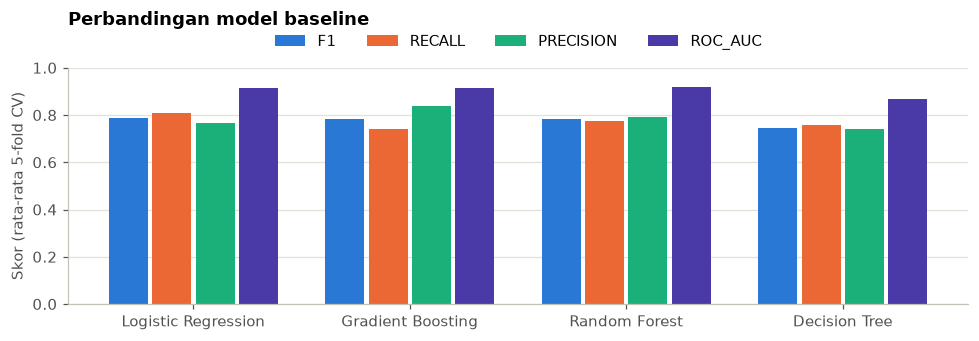

In [26]:
fig, ax = plt.subplots(figsize=(9, 3.2))
metrics_plot = ["f1", "recall", "precision", "roc_auc"]
x = np.arange(len(baseline))
width = 0.2
colors = ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"]
for i, (m, c) in enumerate(zip(metrics_plot, colors)):
    ax.bar(x + (i - 1.5) * width, baseline[m], width=width - 0.02, color=c, label=m.upper())
ax.set_xticks(x, baseline.index)
ax.set_ylim(0, 1)
ax.set_ylabel("Skor (rata-rata 5-fold CV)")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.2))
ax.grid(axis="x", visible=False)
ax.set_title("Perbandingan model baseline", pad=28)
plt.tight_layout()
plt.show()

**Insight:**
- **Logistic Regression, Random Forest, dan Gradient Boosting memiliki performa yang hampir setara** (F1 0,783–0,785, ROC-AUC sekitar 0,915). Decision Tree tunggal tertinggal (F1 0,747).
- **Logistic Regression dipilih** karena:
  1. memiliki F1-score dan **recall tertinggi (0,807)**, artinya paling banyak menangkap mahasiswa yang benar-benar dropout, sesuai tujuan deteksi dini;
  2. **mudah diinterpretasi** oleh pihak institusi (setiap fitur memiliki arah pengaruh yang jelas);
  3. ringan dan cepat, cocok untuk prototype aplikasi.
- Gradient Boosting memiliki precision lebih tinggi (0,836), tetapi recall-nya lebih rendah (0,739). Artinya lebih banyak mahasiswa berisiko yang terlewat.

### 2. Validasi seleksi fitur
Untuk memastikan seleksi 20 fitur tidak mengorbankan performa, model terbaik dibandingkan antara menggunakan **20 fitur terpilih** dan **seluruh 36 fitur asli**.

In [27]:
best_baseline_name = baseline["f1"].idxmax()
all_nominal = [c for c in nominal_codes]
all_numeric = [c for c in df.columns if c not in all_nominal + ["Status"]]
full_pipe = build_pipeline(candidates[best_baseline_name], numeric=all_numeric,
                           categorical=all_nominal, engineer=True)
X_train_full = df.loc[X_train.index].drop(columns="Status")

res_full = cross_validate(full_pipe, X_train_full, y_train, cv=cv, scoring=SCORING)
comparison = pd.DataFrame({
    "36 fitur (semua)": {m: res_full[f"test_{m}"].mean() for m in SCORING},
    "20 fitur (terpilih)": baseline.loc[best_baseline_name, SCORING],
}).T
print("Model:", best_baseline_name)
comparison.round(3)

Model: Logistic Regression


,f1,recall,precision,roc_auc,accuracy
36 fitur (semua),0.789,0.812,0.768,0.922,0.860
20 fitur (terpilih),0.785,0.807,0.766,0.915,0.858


**Insight:** Menggunakan seluruh 36 fitur hanya menaikkan F1 sebesar **±0,004** dan ROC-AUC sebesar ±0,007, perbedaan yang sangat kecil. Dengan 20 fitur, model tetap akurat, sementara data yang perlu diinput pengguna aplikasi berkurang hampir setengahnya. **Seleksi fitur dipertahankan.**

### 3. Hyperparameter tuning
Model dengan F1-score baseline terbaik di-*tuning* menggunakan `GridSearchCV` (5-fold, metrik F1).

In [28]:
param_grids = {
    "Logistic Regression": {"model__C": [0.01, 0.1, 0.3, 1, 3, 10]},
    "Decision Tree": {"model__max_depth": [4, 6, 8, 10], "model__min_samples_leaf": [1, 10, 30]},
    "Random Forest": {"model__n_estimators": [300, 500], "model__max_depth": [None, 10, 20],
                      "model__min_samples_leaf": [1, 3, 5]},
    "Gradient Boosting": {"model__n_estimators": [100, 200, 300], "model__learning_rate": [0.05, 0.1],
                          "model__max_depth": [2, 3, 4]},
}
grid = GridSearchCV(build_pipeline(candidates[best_baseline_name]), param_grids[best_baseline_name],
                    scoring="f1", cv=cv, n_jobs=-1)
grid.fit(X_train, y_train)
print("Model          :", best_baseline_name)
print("Best params    :", grid.best_params_)
print(f"CV F1 baseline : {baseline.loc[best_baseline_name, 'f1']:.3f}")
print(f"CV F1 tuned    : {grid.best_score_:.3f}")
best_pipeline = grid.best_estimator_

Model          : Logistic Regression
Best params    : {'model__C': 10}
CV F1 baseline : 0.785
CV F1 tuned    : 0.788


### 4. Menentukan threshold keputusan
Secara default, model memprediksi *Dropout* jika probabilitasnya ≥ 0,5. Namun, bagi institusi, **melewatkan mahasiswa yang benar-benar akan dropout (false negative) lebih merugikan** daripada memberikan bimbingan kepada mahasiswa yang sebenarnya aman (false positive), karena biaya satu sesi bimbingan jauh lebih kecil daripada kehilangan seorang mahasiswa.

Karena itu ditetapkan aturan bisnis: **model harus mampu menangkap minimal 80% mahasiswa dropout (recall ≥ 0,80)**. Di antara threshold yang memenuhi syarat tersebut, dipilih threshold dengan F1-score tertinggi agar jumlah alarm palsu tetap terkendali. Threshold dipilih menggunakan **prediksi out-of-fold pada data latih**, sehingga data uji tetap tidak disentuh.

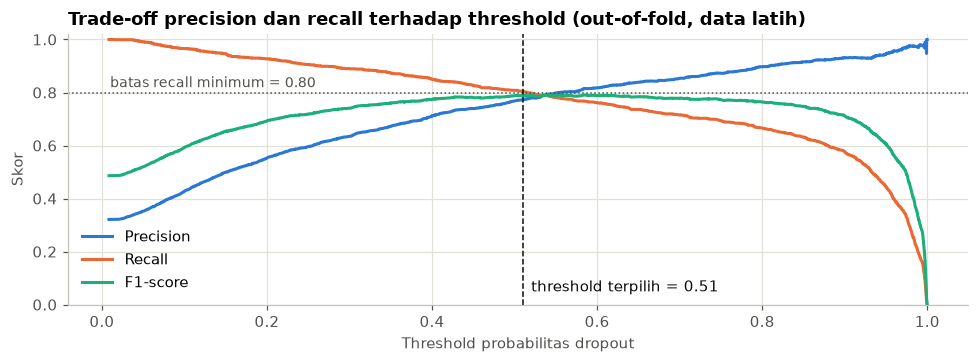

Threshold terpilih: 0.51 | precision 0.776 | recall 0.802 | F1 0.789


In [29]:
MIN_RECALL = 0.80
oof_proba = cross_val_predict(best_pipeline, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
precision, recall, thresholds = precision_recall_curve(y_train, oof_proba)
f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
eligible = np.where(recall[:-1] >= MIN_RECALL)[0]
best_idx = int(eligible[np.argmax(f1_scores[eligible])])
THRESHOLD = float(np.floor(thresholds[best_idx] * 100) / 100)

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(thresholds, precision[:-1], color="#2a78d6", lw=2, label="Precision")
ax.plot(thresholds, recall[:-1], color="#eb6834", lw=2, label="Recall")
ax.plot(thresholds, f1_scores, color="#1baf7a", lw=2, label="F1-score")
ax.axhline(MIN_RECALL, color=MUTED, ls=":", lw=1)
ax.text(0.01, MIN_RECALL + 0.02, f"batas recall minimum = {MIN_RECALL:.2f}", color=MUTED, fontsize=9)
ax.axvline(THRESHOLD, color=INK, ls="--", lw=1)
ax.text(THRESHOLD + 0.01, 0.05, f"threshold terpilih = {THRESHOLD:.2f}", color=INK)
ax.set_xlabel("Threshold probabilitas dropout")
ax.set_ylabel("Skor")
ax.set_ylim(0, 1.02)
ax.legend(loc="lower left")
ax.set_title("Trade-off precision dan recall terhadap threshold (out-of-fold, data latih)")
plt.tight_layout()
plt.show()
print(f"Threshold terpilih: {THRESHOLD:.2f} | precision {precision[best_idx]:.3f} | "
      f"recall {recall[best_idx]:.3f} | F1 {f1_scores[best_idx]:.3f}")

**Insight:**
- Semakin rendah threshold, recall semakin tinggi (lebih banyak mahasiswa berisiko tertangkap), tetapi precision turun (lebih banyak alarm palsu).
- Threshold yang memenuhi syarat recall ≥ 0,80 dengan F1 tertinggi adalah **0,51**. Pada data latih (out-of-fold), threshold ini menghasilkan recall ±0,80 dan precision ±0,78.
- Threshold ini disimpan bersama model dan dipakai di aplikasi. Selain label Dropout/Non-Dropout, aplikasi juga menampilkan **tingkat risiko** (Rendah / Sedang / Tinggi) berdasarkan probabilitas agar staf dapat memprioritaskan intervensi.

## Evaluation

### 1. Performa pada data uji
Model final dievaluasi **satu kali** pada data uji (20%) yang belum pernah dilihat selama training, tuning, maupun pemilihan threshold.

In [30]:
test_proba = best_pipeline.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= THRESHOLD).astype(int)

print(f"Threshold = {THRESHOLD:.2f}\n")
print(classification_report(y_test, test_pred, target_names=["Non-Dropout", "Dropout"], digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, test_proba):.3f}")

test_metrics = {
    "f1": f1_score(y_test, test_pred),
    "recall": recall_score(y_test, test_pred),
    "precision": precision_score(y_test, test_pred),
    "accuracy": float((test_pred == y_test).mean()),
    "roc_auc": roc_auc_score(y_test, test_proba),
}

Threshold = 0.51

              precision    recall  f1-score   support

 Non-Dropout      0.911     0.907     0.909       601
     Dropout      0.805     0.813     0.809       284

    accuracy                          0.877       885
   macro avg      0.858     0.860     0.859       885
weighted avg      0.877     0.877     0.877       885

ROC-AUC: 0.929


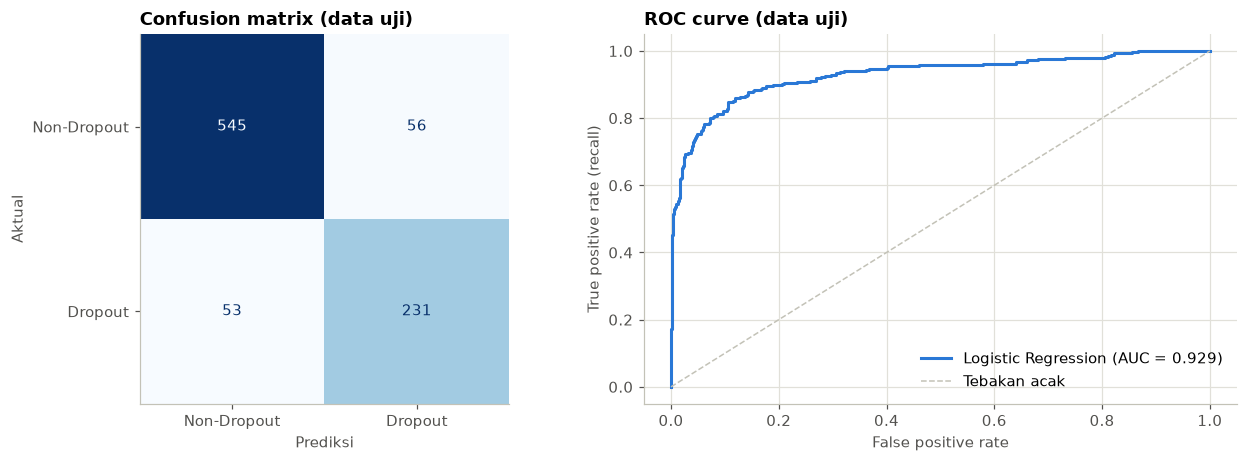

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_pred, display_labels=["Non-Dropout", "Dropout"], cmap="Blues",
    colorbar=False, ax=axes[0])
axes[0].grid(False)
axes[0].set_title("Confusion matrix (data uji)")
axes[0].set_xlabel("Prediksi")
axes[0].set_ylabel("Aktual")

fpr, tpr, _ = roc_curve(y_test, test_proba)
axes[1].plot(fpr, tpr, color="#2a78d6", lw=2, label=f"{best_baseline_name} (AUC = {test_metrics['roc_auc']:.3f})")
axes[1].plot([0, 1], [0, 1], color=NEUTRAL, ls="--", lw=1, label="Tebakan acak")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate (recall)")
axes[1].legend(loc="lower right")
axes[1].set_title("ROC curve (data uji)")
plt.tight_layout()
plt.show()

**Insight:**
- Pada data uji, model menghasilkan **recall 81,3%**, **precision 80,5%**, **F1-score 0,809**, **akurasi 87,7%**, dan **ROC-AUC 0,929**. Performa ini konsisten dengan hasil cross-validation, sehingga model **tidak overfit**.
- Dari 284 mahasiswa yang benar-benar dropout, **231 berhasil terdeteksi** dan hanya 53 yang terlewat.
- Dari 287 mahasiswa yang diprediksi dropout, 231 (80%) memang dropout. Artinya, **4 dari 5 mahasiswa yang ditandai model benar-benar berisiko**, sehingga sumber daya bimbingan tidak banyak terbuang.
- ROC-AUC 0,929 menunjukkan model sangat baik dalam **mengurutkan** mahasiswa dari yang paling berisiko hingga paling aman.

### 2. Validasi tingkat risiko
Probabilitas dropout dikelompokkan menjadi tiga tingkat risiko agar mudah ditindaklanjuti. Tabel berikut memeriksa dropout rate aktual pada setiap tingkat di data uji.

In [32]:
RISK_LOW_MAX = 0.25
risk_level = pd.cut(test_proba, bins=[0, RISK_LOW_MAX, THRESHOLD, 1.0001], right=False,
                    labels=["Rendah", "Sedang", "Tinggi"])
risk_table = (pd.DataFrame({"risk": risk_level, "actual_dropout": y_test.values})
              .groupby("risk", observed=True)["actual_dropout"]
              .agg(jumlah_mahasiswa="size", dropout_rate_aktual="mean"))
risk_table["dropout_rate_aktual"] = risk_table["dropout_rate_aktual"].map("{:.1%}".format)
risk_table

,jumlah_mahasiswa,dropout_rate_aktual
risk,,
Rendah,453,4.9%
Sedang,145,21.4%
Tinggi,287,80.5%


**Insight:** Tingkat risiko terbukti bermakna:
- **Risiko Rendah** (probabilitas < 25%): hanya sekitar 5% yang benar-benar dropout. Cukup dipantau secara rutin.
- **Risiko Sedang** (25% hingga di bawah threshold): sekitar 21% dropout. Perlu dipantau lebih dekat oleh dosen wali.
- **Risiko Tinggi** (≥ threshold): sekitar 80% dropout. **Prioritas utama untuk bimbingan khusus.**

### 3. Faktor paling berpengaruh menurut model
*Permutation importance* mengukur seberapa besar penurunan ROC-AUC ketika nilai suatu fitur diacak. Semakin besar penurunannya, semakin penting fitur tersebut bagi model. Metode ini diterapkan pada 20 fitur mentah sehingga hasilnya mudah dibaca.

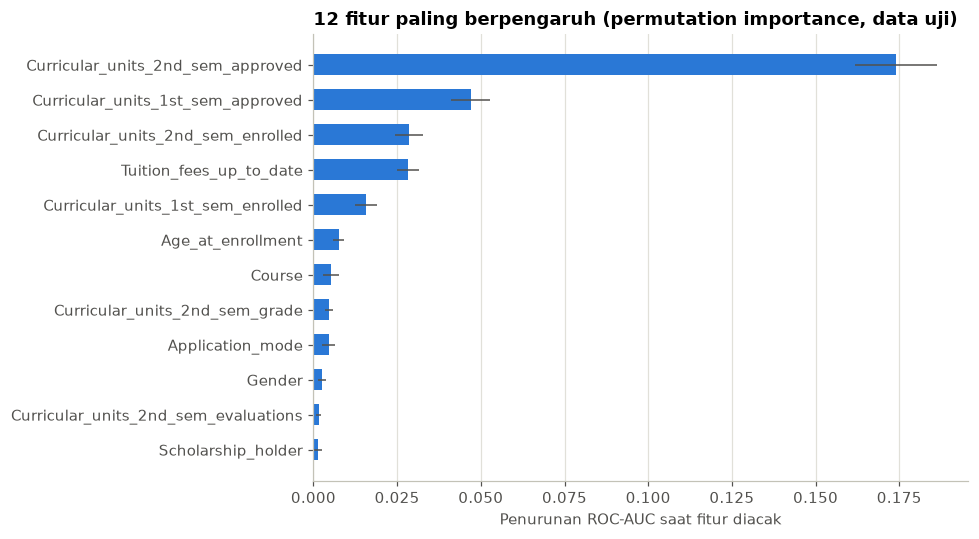

,importance,std
Curricular_units_2nd_sem_approved,0.1740,0.0122
Curricular_units_1st_sem_approved,0.0470,0.0058
Curricular_units_2nd_sem_enrolled,0.0285,0.0041
Tuition_fees_up_to_date,0.0282,0.0032
Curricular_units_1st_sem_enrolled,0.0156,0.0032
Age_at_enrollment,0.0075,0.0016
Course,0.0053,0.0023
Curricular_units_2nd_sem_grade,0.0047,0.0012
Application_mode,0.0045,0.0018
Gender,0.0026,0.0011


In [33]:
perm = permutation_importance(best_pipeline, X_test, y_test, scoring="roc_auc",
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
importance = (pd.DataFrame({"importance": perm.importances_mean, "std": perm.importances_std},
                           index=X_test.columns)
              .sort_values("importance", ascending=True))

top = importance.tail(12)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top.index, top["importance"], xerr=top["std"], color="#2a78d6", height=0.6,
        error_kw={"ecolor": MUTED, "lw": 1})
ax.set_xlabel("Penurunan ROC-AUC saat fitur diacak")
ax.grid(axis="y", visible=False)
ax.set_title("12 fitur paling berpengaruh (permutation importance, data uji)")
plt.tight_layout()
plt.show()
importance.sort_values("importance", ascending=False).round(4).head(12)

**Insight:**
- **Jumlah MK yang lulus di semester 2** adalah fitur paling dominan, jauh di atas fitur lain. Disusul **jumlah MK lulus di semester 1**, **jumlah MK yang diambil**, dan **status pembayaran uang kuliah**.
- Faktor berikutnya adalah **usia saat mendaftar, program studi, nilai semester 2, jalur masuk, gender, dan status beasiswa**.
- Hasil ini **konsisten dengan temuan EDA**: sinyal akademik semester awal dan kondisi finansial adalah indikator utama dropout. Keduanya merupakan faktor yang **dapat dipantau dan diintervensi** oleh institusi.

### 4. Menyimpan model
Model disimpan sebagai satu pipeline utuh (feature engineering + preprocessing + model) dengan `joblib`. Metadata (fitur, threshold, dan metrik) disimpan terpisah dalam format JSON untuk digunakan aplikasi Streamlit.

In [34]:
joblib.dump(best_pipeline, "model/dropout_model.joblib")

metadata = {
    "model_name": best_baseline_name,
    "best_params": {k.replace("model__", ""): v for k, v in grid.best_params_.items()},
    "threshold": THRESHOLD,
    "risk_low_max": RISK_LOW_MAX,
    "features": MODEL_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "numeric_features": NUMERIC_FEATURES,
    "test_metrics": {k: round(float(v), 4) for k, v in test_metrics.items()},
    "feature_importance": importance["importance"].sort_values(ascending=False).round(4).to_dict(),
    "sklearn_version": sklearn.__version__,
}
with open("model/model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

# Contoh berkas input untuk fitur prediksi batch di aplikasi
sample = X_test.sample(25, random_state=RANDOM_STATE).copy()
sample.insert(0, "Student_id", [f"STD-{i:03d}" for i in range(1, len(sample) + 1)])
sample.to_csv("data/contoh_input_batch.csv", index=False)
print(json.dumps({k: v for k, v in metadata.items() if k != "feature_importance"}, indent=2))

{
  "model_name": "Logistic Regression",
  "best_params": {
    "C": 10
  },
  "threshold": 0.51,
  "risk_low_max": 0.25,
  "features": [
    "Marital_status",
    "Application_mode",
    "Course",
    "Daytime_evening_attendance",
    "Admission_grade",
    "Previous_qualification_grade",
    "Displaced",
    "Debtor",
    "Tuition_fees_up_to_date",
    "Gender",
    "Scholarship_holder",
    "Age_at_enrollment",
    "Curricular_units_1st_sem_enrolled",
    "Curricular_units_1st_sem_evaluations",
    "Curricular_units_1st_sem_approved",
    "Curricular_units_1st_sem_grade",
    "Curricular_units_2nd_sem_enrolled",
    "Curricular_units_2nd_sem_evaluations",
    "Curricular_units_2nd_sem_approved",
    "Curricular_units_2nd_sem_grade"
  ],
  "categorical_features": [
    "Marital_status",
    "Application_mode",
    "Course"
  ],
  "numeric_features": [
    "Daytime_evening_attendance",
    "Admission_grade",
    "Previous_qualification_grade",
    "Displaced",
    "Debtor",
    "Tuiti

Uji coba memuat ulang model dan melakukan prediksi pada data baru (disimulasikan dengan 5 data uji):

In [35]:
loaded = joblib.load("model/dropout_model.joblib")
demo = X_test.head(5).copy()
demo["Prob_dropout"] = loaded.predict_proba(demo)[:, 1].round(3)
demo["Prediksi"] = np.where(demo["Prob_dropout"] >= THRESHOLD, "Dropout", "Non-Dropout")
demo["Aktual"] = y_test.head(5).map({1: "Dropout", 0: "Non-Dropout"}).values
demo[["Course", "Age_at_enrollment", "Tuition_fees_up_to_date", "Curricular_units_2nd_sem_approved",
      "Prob_dropout", "Prediksi", "Aktual"]]

,Course,Age_at_enrollment,Tuition_fees_up_to_date,Curricular_units_2nd_sem_approved,Prob_dropout,Prediksi,Aktual
2892,9670,18,1,6,0.066,Non-Dropout,Non-Dropout
2555,9119,18,1,2,0.503,Non-Dropout,Non-Dropout
2266,9003,50,1,1,0.977,Dropout,Dropout
3757,9500,18,1,8,0.036,Non-Dropout,Non-Dropout
3861,9773,18,1,0,0.988,Dropout,Dropout


## Kesimpulan

**Menjawab permasalahan bisnis:**

1. **Seberapa besar tingkat dropout?** Sebanyak **32,1% mahasiswa (1.421 dari 4.424) dropout**, sekitar 1 dari 3 mahasiswa.

2. **Faktor apa saja yang paling berkaitan dengan dropout?**
   - **Akademik (paling kuat):** sedikitnya MK yang lulus dan rendahnya nilai di semester 1–2. Mahasiswa yang tidak lulus satu pun MK di semester 2 memiliki dropout rate 84%.
   - **Finansial:** uang kuliah yang menunggak (87% dropout), memiliki utang (62%), dan tidak menerima beasiswa (39% vs 12% pada penerima beasiswa).
   - **Demografis:** usia masuk ≥25 tahun (>50% dropout), laki-laki (45% vs 25%), sudah menikah, dan kuliah malam.
   - **Jalur masuk & prodi:** jalur *Over 23 years old* (55%) dan *Holders of other higher courses* (61%), serta prodi Equinculture, Informatics Engineering, dan Management (malam) dengan dropout rate di atas 50%.
   - Latar belakang pendidikan orang tua dan kondisi makroekonomi **tidak** berpengaruh berarti.

3. **Bagaimana mendeteksi mahasiswa berisiko sejak dini?** Model **Logistic Regression** dengan 20 fitur mampu mendeteksi **81% mahasiswa yang akan dropout** dengan precision 80% (F1 0,81; ROC-AUC 0,93) pada data uji. Model dilengkapi tingkat risiko **Rendah / Sedang / Tinggi** dan di-*deploy* sebagai prototype aplikasi Streamlit.

4. **Bagaimana memonitor performa mahasiswa?** Data yang sudah dibersihkan (`data/students_clean.csv`) digunakan untuk dashboard Metabase yang menampilkan faktor-faktor di atas.